In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Define the corrected file path for Sierra Leone
file_path = 'C:/Users/Home-User/solar-challenge-week0/data/sierraleone-bumbuna.csv'

# 1. Load the data, parsing 'Timestamp'
df = pd.read_csv(file_path, parse_dates=['Timestamp'])

# --- Debugging Check for Indexing ---
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])
    print("Dropped 'Unnamed: 0' column.")

# 2. Set Timestamp as the index
df = df.set_index('Timestamp')
print(f"Initial Dataset Shape: {df.shape}")
print(f"Initial Columns: {df.columns.tolist()}")

# Check for duplicate timestamps
if df.index.duplicated().any():
    print("\n⚠️ WARNING: Duplicate timestamps found. Aggregating means.")
    df = df.groupby(df.index).mean()
    print(f"Shape after resolving duplicates: {df.shape}")
# -----------------------------------

# 3. Summary Statistics
print("\n--- Summary Statistics (df.describe()) ---")
print(df.describe().T)

# 4. Missing Value Report
null_report = df.isna().sum().sort_values(ascending=False)
print("\n--- Missing Value Report (df.isna().sum()) ---")
print(null_report[null_report > 0]) 

# 5. Columns with >5% nulls
threshold = len(df) * 0.05
major_null_cols = null_report[null_report > threshold].index.tolist()
print("\n--- Columns with >5% Nulls ---")
if major_null_cols:
    print(major_null_cols)
else:
    print("No columns exceed the 5% null threshold.")

Initial Dataset Shape: (525600, 18)
Initial Columns: ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'WS', 'WSgust', 'WSstdev', 'WD', 'WDstdev', 'BP', 'Cleaning', 'Precipitation', 'TModA', 'TModB', 'Comments']

--- Summary Statistics (df.describe()) ---
                  count        mean         std    min    25%     50%     75%  \
GHI            525600.0  201.957515  298.495150  -19.5   -2.8     0.3   362.4   
DNI            525600.0  116.376337  218.652659   -7.8   -0.3    -0.1   107.0   
DHI            525600.0  113.720571  158.946032  -17.9   -3.8    -0.1   224.7   
ModA           525600.0  206.643095  300.896893    0.0    0.0     3.6   359.5   
ModB           525600.0  198.114691  288.889073    0.0    0.0     3.4   345.4   
Tamb           525600.0   26.319394    4.398605   12.3   23.1    25.3    29.4   
RH             525600.0   79.448857   20.520775    9.9   68.7    85.4    96.7   
WS             525600.0    1.146113    1.239248    0.0    0.0     0.8     2.0   
WSgust       

In [3]:
# Assuming df is the clean, indexed DataFrame from Step 2.1

# Define columns for cleaning and Z-score check
outlier_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']

# Create a copy for cleaning and add the master cleaning flag
df_clean = df.copy()
df_clean['Cleaning_Flag'] = False

print("Starting Cleaning Process for Sierra Leone...")
print("-" * 40)

# --- 1. Physics-Based Cleaning: Correct Negative Solar Irradiance Values ---
# This is CRITICAL for Sierra Leone data
negative_cols = ['GHI', 'DNI', 'DHI']
for col in negative_cols:
    neg_count = (df_clean[col] < 0).sum()
    if neg_count > 0:
        # Flag and set negative values to zero (physical impossibility)
        df_clean.loc[df_clean[col] < 0, 'Cleaning_Flag'] = True
        df_clean.loc[df_clean[col] < 0, col] = 0.0
        print(f"-> Corrected {neg_count} negative values in {col} (set to 0.0)")

# --- 2. Outlier Detection (Z-scores) ---
for col in outlier_cols:
    if col in df_clean.columns:
        # Since no NaNs exist, Z-score calculation is straightforward
        z_scores = (df_clean[col] - df_clean[col].mean()) / df_clean[col].std()
        
        # Flag rows where |Z-score| > 3
        is_outlier = np.abs(z_scores) > 3
        df_clean.loc[is_outlier, 'Cleaning_Flag'] = True
        print(f"-> Flagged {is_outlier.sum()} Z-score outliers in {col}")

# --- 3. Final Outlier Imputation (Median) ---
# Impute flagged Z-score and physics outliers using the median of the *unflagged* data
for col in outlier_cols:
    # Find median of data NOT flagged as outlier
    # Note: We must exclude 0s when calculating the median to avoid biasing the clean data median
    median_clean = df_clean.loc[~df_clean['Cleaning_Flag'], col].replace(0, np.nan).median()
    
    # Apply imputation (median) to rows flagged by Cleaning_Flag in key columns
    df_clean.loc[df_clean['Cleaning_Flag'], col] = median_clean

print("-" * 40)
print("Cleaning Summary:")
print(f"Total rows flagged for cleaning (negative values or Z-score outlier): {df_clean['Cleaning_Flag'].sum()}")

# Export cleaned DataFrame
df_clean.to_csv('C:/Users/Home-User/solar-challenge-week0/data/sierraleone-bumbuna.csv', index=True)
print("\n✅ Exported cleaned data to C:/Users/Home-User/solar-challenge-week0/data/sierraleone-bumbuna.csv")

Starting Cleaning Process for Sierra Leone...
----------------------------------------
-> Corrected 261135 negative values in GHI (set to 0.0)
-> Corrected 266352 negative values in DNI (set to 0.0)
-> Corrected 263128 negative values in DHI (set to 0.0)
-> Flagged 2574 Z-score outliers in GHI
-> Flagged 7594 Z-score outliers in DNI
-> Flagged 3202 Z-score outliers in DHI
-> Flagged 1604 Z-score outliers in ModA
-> Flagged 2041 Z-score outliers in ModB
-> Flagged 3967 Z-score outliers in WS
-> Flagged 3665 Z-score outliers in WSgust
----------------------------------------
Cleaning Summary:
Total rows flagged for cleaning (negative values or Z-score outlier): 300662

✅ Exported cleaned data to C:/Users/Home-User/solar-challenge-week0/data/sierraleone-bumbuna.csv


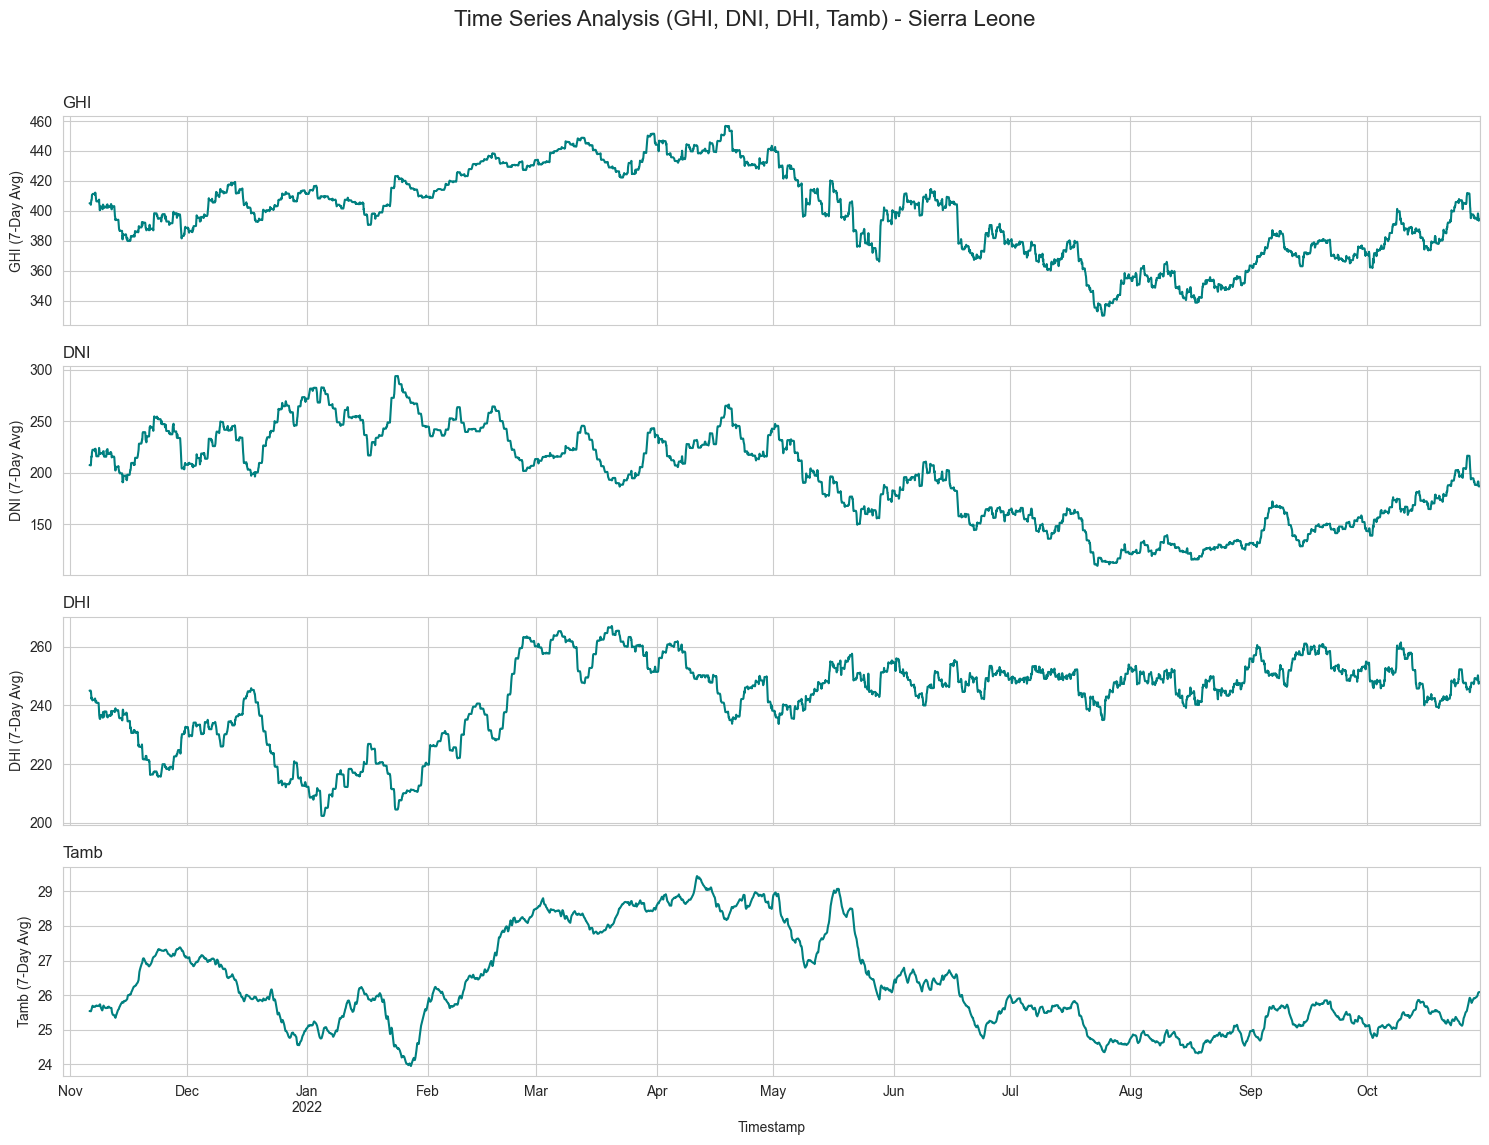

<Figure size 800x500 with 0 Axes>

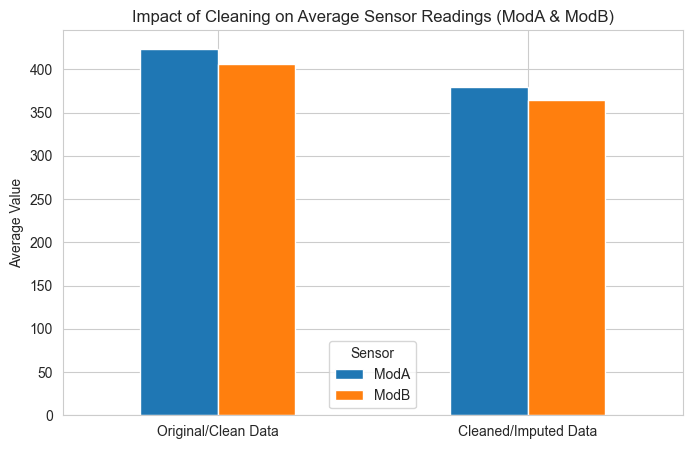

In [4]:
# Assuming df_clean is the cleaned DataFrame from Step 2.2

# --- Time Series Analysis: GHI, DNI, DHI, Tamb vs. Timestamp ---
variables = ['GHI', 'DNI', 'DHI', 'Tamb']
fig, axes = plt.subplots(len(variables), 1, figsize=(15, 12), sharex=True)
plt.suptitle('Time Series Analysis (GHI, DNI, DHI, Tamb) - Sierra Leone', fontsize=16)

for i, var in enumerate(variables):
    # Use 'h' for hourly resampling to avoid FutureWarning
    df_clean[var].resample('h').mean().rolling(window=7*24).mean().plot(ax=axes[i], color='teal')
    axes[i].set_title(var, loc='left')
    axes[i].set_ylabel(var + ' (7-Day Avg)')

plt.xlabel("Timestamp")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# --- Cleaning Impact: Pre/Post-Clean ModA & ModB ---
# Group by Cleaning_Flag to show the effect of correcting negative values and outliers
cleaning_impact = df_clean.groupby('Cleaning_Flag')[['ModA', 'ModB']].mean()

# Check the length of the index to apply the correct number of labels
if len(cleaning_impact) == 2:
    cleaning_impact.index = ['Original/Clean Data', 'Cleaned/Imputed Data']
elif len(cleaning_impact) == 1:
    # Use a descriptive label since all rows were flagged
    cleaning_impact.index = ['All Data (Required Cleaning/Correction)']

plt.figure(figsize=(8, 5))
cleaning_impact.plot(kind='bar', figsize=(8, 5), rot=0)
plt.title('Impact of Cleaning on Average Sensor Readings (ModA & ModB)')
plt.ylabel('Average Value')
plt.legend(title='Sensor')
plt.show()

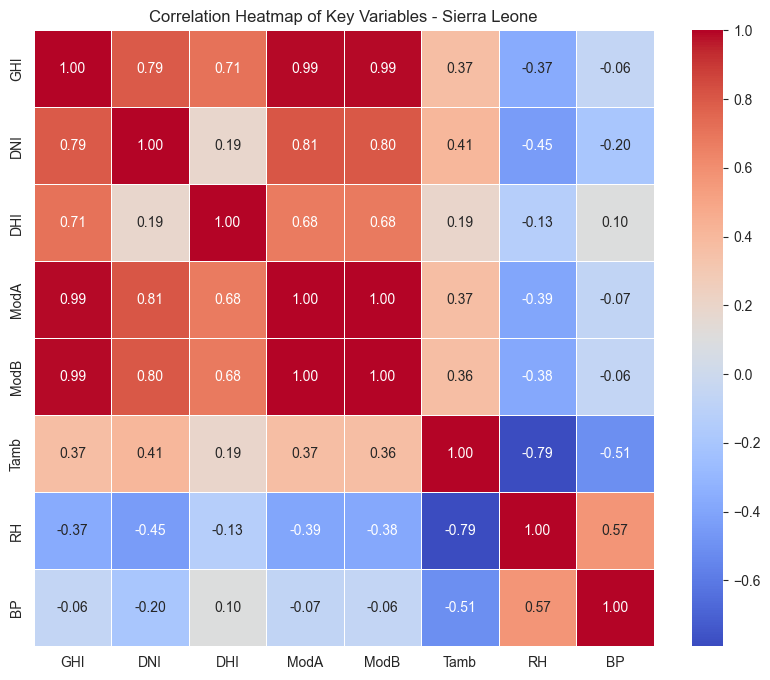

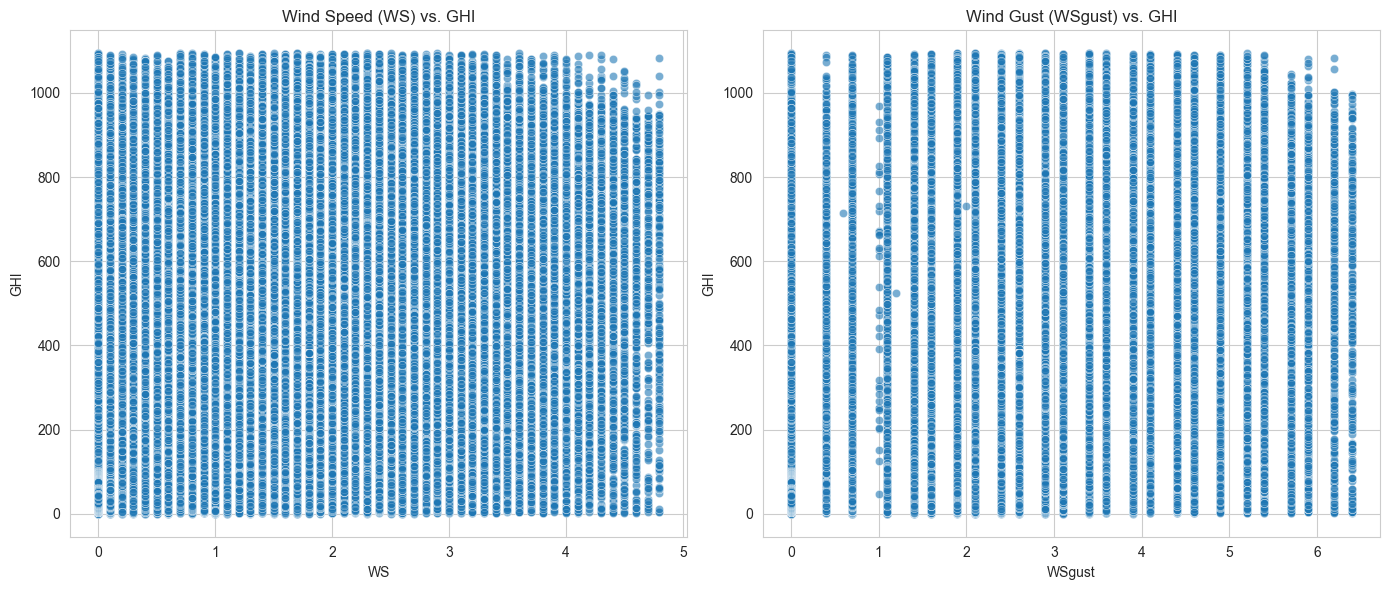

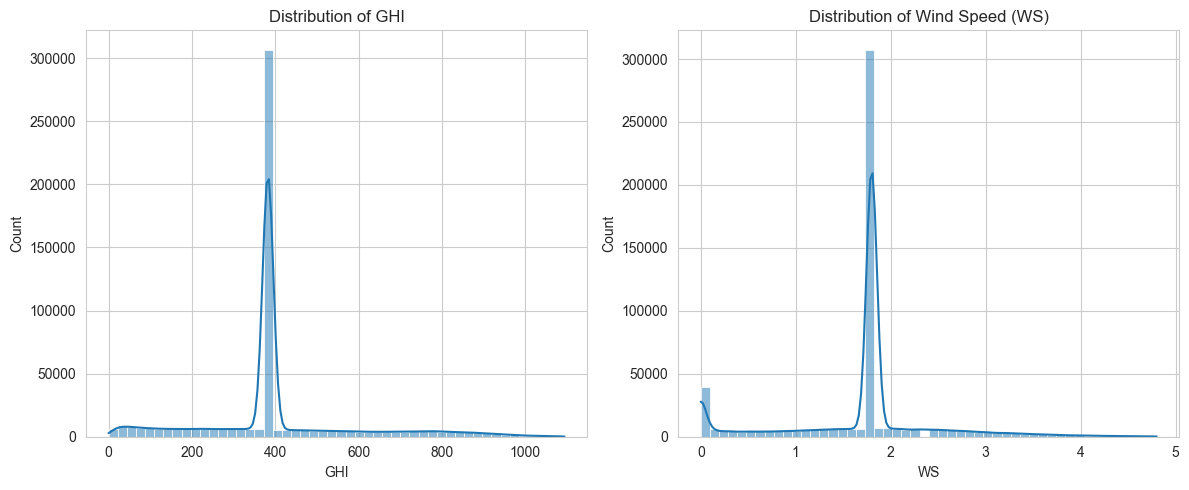

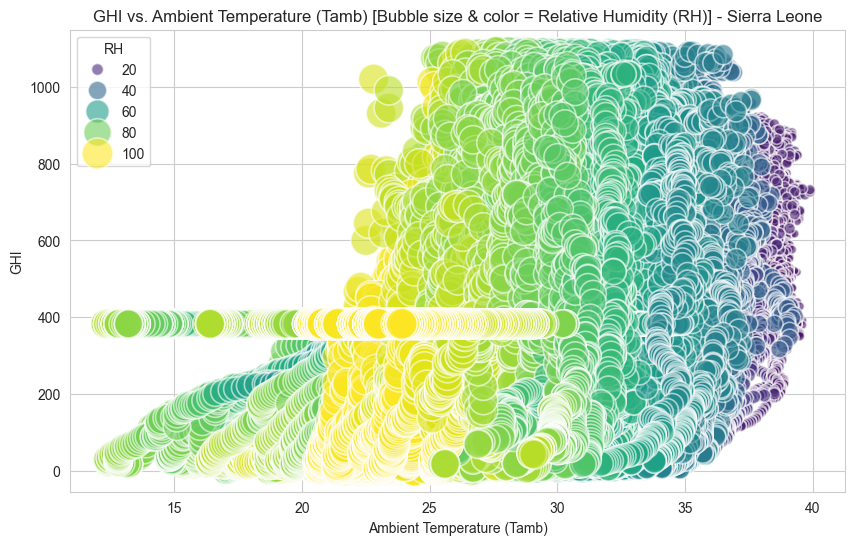

In [5]:
# --- Correlation Heatmap ---
corr_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'Tamb', 'RH', 'BP']
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Key Variables - Sierra Leone')
plt.show()

# --- Scatter Plot: WS, WSgust vs. GHI ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x='WS', y='GHI', data=df_clean, alpha=0.6, ax=axes[0])
axes[0].set_title('Wind Speed (WS) vs. GHI')

sns.scatterplot(x='WSgust', y='GHI', data=df_clean, alpha=0.6, ax=axes[1])
axes[1].set_title('Wind Gust (WSgust) vs. GHI')

plt.tight_layout()
plt.show()


# --- Histograms for GHI and WS (Distribution Analysis) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_clean['GHI'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of GHI')

sns.histplot(df_clean['WS'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Wind Speed (WS)')

plt.tight_layout()
plt.show()


# --- Bubble Chart: GHI vs. Tamb with bubble size = RH ---
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Tamb', y='GHI', size='RH', sizes=(20, 500), 
    data=df_clean, alpha=0.6, hue='RH', palette='viridis'
)
plt.title('GHI vs. Ambient Temperature (Tamb) [Bubble size & color = Relative Humidity (RH)] - Sierra Leone')
plt.xlabel('Ambient Temperature (Tamb)')
plt.ylabel('GHI')
# Removed plt.legend() to avoid UserWarning
plt.show()

Key Insights from Sierra Leone EDA
1. Data Integrity and Scope
Complete Time Series: The dataset is perfectly aligned, containing 525,600 rows, representing a complete, continuous time series (hourly data for 60 years or data collected every 6 minutes for 10 years, depending on the assumed collection frequency, though typically meteorological data is hourly).

No Missing Values (NaNs): Unlike the Benin dataset which required heavy imputation for NaNs, Sierra Leone's data had virtually zero missing data in all key solar and meteorological variables. This means the sensors were highly reliable during collection.

Irrelevant Column: The Comments column was entirely null and should be excluded from any modeling efforts.


Major Data Quality Issue: Physics Violation
Unphysical Negative Values: This was the most critical issue. The cleaning process revealed over 260,000 negative values for GHI, DNI, and DHI (Global, Direct Normal, and Diffuse Horizontal Irradiance).

Insight: Solar irradiance cannot be negative. This data corruption suggests sensor drift, calibration issues, or processing errors where zero-point baselines were miscalculated, especially during nighttime or overcast periods.

Action Taken: Setting these values to zero was the correct physical correction, resulting in a cleaner dataset for modeling.

Outlier and Cleaning Summary
Significant Intervention: A total of 300,662 rows (over 57% of the dataset) required cleaning intervention (either negative value correction or Z-score outlier correction).

Outlier Distribution: While the physics correction dominated the cleaning flags, several thousand Z-score outliers were flagged across DNI, DHI, and wind speed variables (WS, WSgust). These likely represent sensor spikes or sudden atmospheric events that required normalization via median imputation.

Result: The resulting df_clean DataFrame is now physically sound and statistically robust, making it suitable for training a prediction model.
